# Download the Dataset

In [2]:
med_insurance_url = 'https://raw.githubusercontent.com/JovianML/opendatasets/master/data/medical-charges.csv'
from urllib.request import urlretrieve
urlretrieve(med_insurance_url, 'medical-charges.csv')

('medical-charges.csv', <http.client.HTTPMessage at 0x2218f19f4d0>)

# Create Pandas Dataframe

In [3]:
import pandas as pd
medical_df = pd.read_csv('medical-charges.csv', on_bad_lines='skip', delimiter=',')
print(medical_df.describe())

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


# Download & Import plotly, matplotlib & seaborn

In [4]:
import matplotlib
import matplotlib.pyplot as plt
import plotly 
import plotly.express as px
import seaborn as sns

In [5]:
medical_df.age.describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

In [6]:
sns.set_style('darkgrid')
matplotlib.rcParams['figure.figsize'] = (10,6)
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.facecolor'] = '#00000000'

fig = px.histogram(medical_df, x = 'age',
                      nbins = 47, title = 'Distribution of Ages',
                      marginal = 'box')
fig.update_layout(bargap = 0.2)

fig.show()

In [7]:
fig = px.histogram(medical_df, x = 'bmi',
                       marginal = 'box', color_discrete_sequence = ['red'],
                       title = 'Distribution of BMI (Gaussian Distibution)')
fig.update_layout(bargap = 0.2)
fig.show()

In [8]:
fig = px.histogram(medical_df, x = 'charges',
                   color = 'smoker', color_discrete_sequence = ['red', 'green'],
                   marginal = 'box', title = 'Distribution of Charges (Exponential Distribution)')
fig.update_layout(bargap = 0.2)
fig.show()

In [9]:
medical_df.smoker.value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [10]:
fig = px.histogram(medical_df, color = 'sex',
                   x = 'smoker', title = 'Distribution of Smokers by their Sex',
                   )
fig.show()

In [11]:
fig = px.scatter(medical_df, x = 'age',
               y = 'charges', color = 'smoker',
               hover_data = ['sex', 'region'], opacity = 1,
               title = 'Age vs Charges')
fig.update_traces(marker_size = 3)
fig.show()

<Axes: xlabel='children', ylabel='charges'>

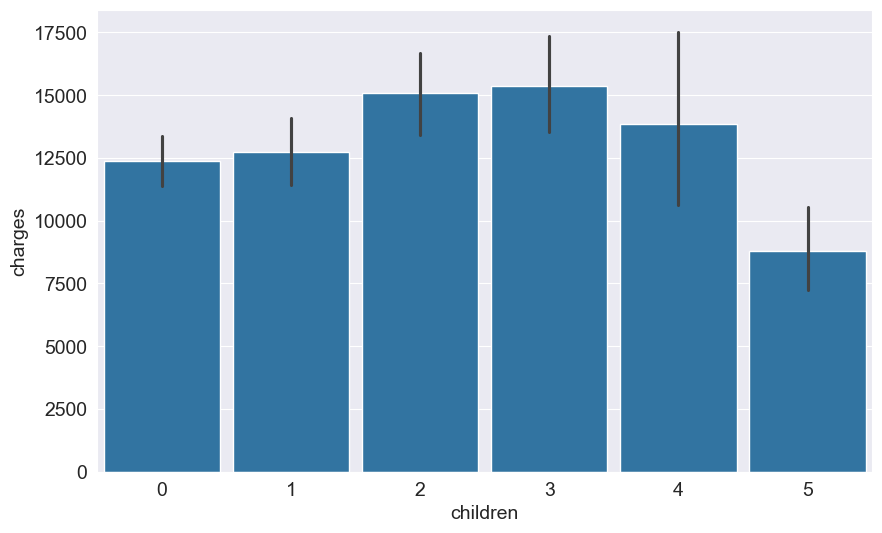

In [25]:
fig = px.violin(medical_df, x = 'children', y = 'charges')
fig.show()
sns.barplot(x = 'children', y = 'charges', data = medical_df, width = 0.9)